<a href="https://colab.research.google.com/github/Feral-Raccoon67/cb2330-portfolio/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [4]:
crossover_classes = [0, 1, 2, 3, 4]
chromosomes = ["2L", "2R", "3L", "3R", "X"]

data = {
    "2L": [375, 336, 62, 10, 0],
    "2R": [154, 107, 20, 6, 1],
    "3L": [346, 329, 99, 7, 2],
    "3R": [294, 348, 95, 15, 4],
    "X":  [354, 331, 64, 5, 0]
}

# Forward running
We run forward by first estiamting theta for each chromosome by calculating the total amount of crossovers over the total amount of meiotic events. We can then use the Poisson model for finding the expected crossover counts of each crossover type for each chromosome. We can then compare it to the observed values.  

In [5]:
def factorial(x):
    """x! as a product, 0! = 1."""
    total = 1
    for k in range(1, x + 1):
        total = total * k
    return total


def poisson(x, theta):
    """p(x | theta) = theta^x e^(-theta) / x!  the probability of x crossovers at rate theta."""
    p = (theta**x * math.exp(-theta))/ factorial(x)
    return p

def theta_estimate(crossover_classes, counts):
  """Returns the total amount of crossovers over the total amount of meiotic events"""
  total_crossovers = 0

  for i in range(len(crossover_classes)):
    x = crossover_classes[i]
    count = counts[i]
    total_crossovers += x * count

  total_events = sum(counts) #Total amount of meiotic events

  return total_crossovers/total_events

2L
theta = 0.63
expected = [418.78 262.07  82.    17.11   2.68]
observed = [375, 336, 62, 10, 0]


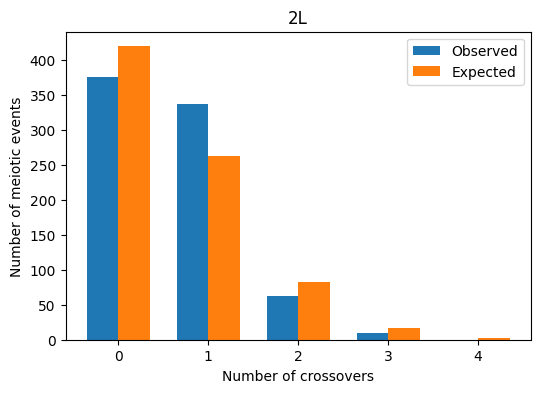

2R
theta = 0.59
expected = [160.16  93.98  27.57   5.39   0.79]
observed = [154, 107, 20, 6, 1]


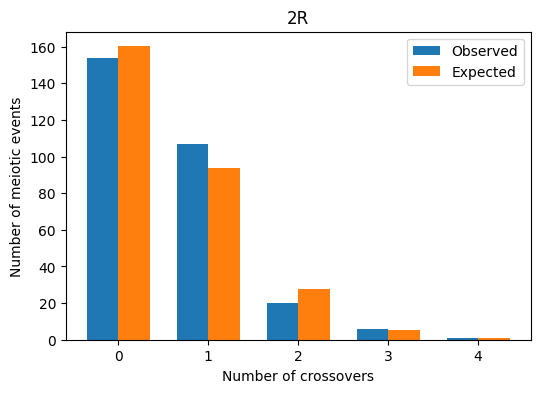

3L
theta = 0.71
expected = [384.92 273.33  97.04  22.97   4.08]
observed = [346, 329, 99, 7, 2]


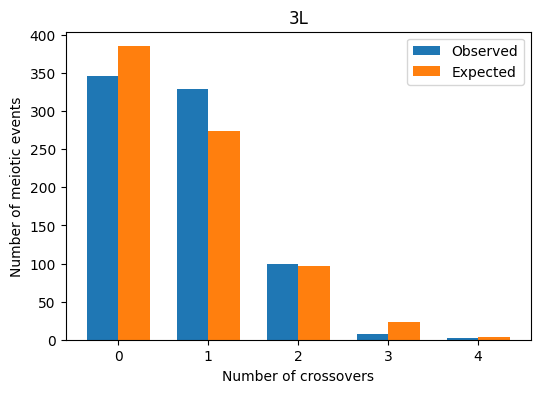

3R
theta = 0.79
expected = [342.31 271.22 107.45  28.38   5.62]
observed = [294, 348, 95, 15, 4]


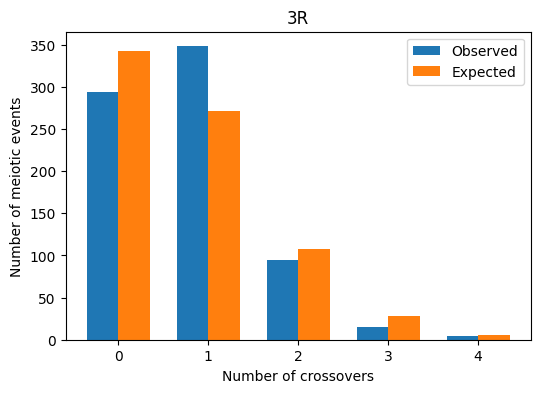

X
theta = 0.63
expected = [402.12 252.79  79.46  16.65   2.62]
observed = [354, 331, 64, 5, 0]


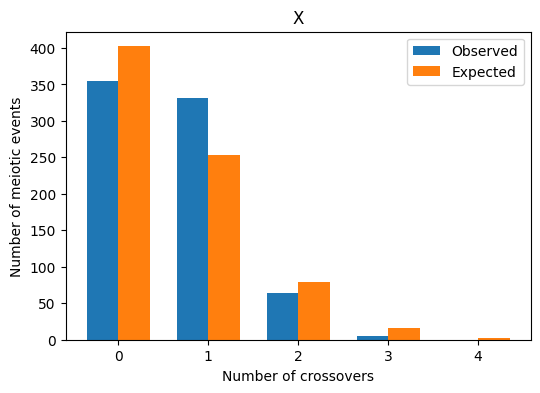

In [6]:
for chromosome in chromosomes:
  counts = data[chromosome]
  theta = theta_estimate(crossover_classes, counts)
  expected = np.zeros(len(crossover_classes))

  for i in range(len(crossover_classes)):
    x = crossover_classes[i]
    expected[i] = poisson(x, theta)*sum(counts)

  print(chromosome)
  print("theta =", round(theta,2))
  print("expected =", expected.round(2))
  print("observed =", counts)

  width = 0.35

  plt.figure(figsize=(6, 4))

  plt.bar(np.array(crossover_classes) - width/2, counts,
          width=width, label="Observed")

  plt.bar(np.array(crossover_classes) + width/2, expected,
            width=width, label="Expected")

  plt.xlabel("Number of crossovers")
  plt.ylabel("Number of meiotic events")
  plt.title(chromosome)
  plt.xticks(crossover_classes)
  plt.legend()

  plt.show()

# Backward running

In [7]:
def likelihood(crossover_classes, counts, theta):
  """L(theta) = .... p(x_i | theta)."""

  total = 1.0

  for i in range(len(crossover_classes)):

      x = crossover_classes[i]
      count = counts[i]

      total *= poisson(x, theta) ** count

  return total


def nLL(crossover_classes, counts, theta):

    total = 0.0

    for i in range(len(crossover_classes)):

        x = crossover_classes[i]
        count = counts[i]

        total -= count * math.log(poisson(x, theta))

    return total

def position_of_min(values):
  """The index of the smallest entry: the position, not the value."""
  best = 0
  for j in range(len(values)):
    if values[j] < values[best]:
      best = j

  return best

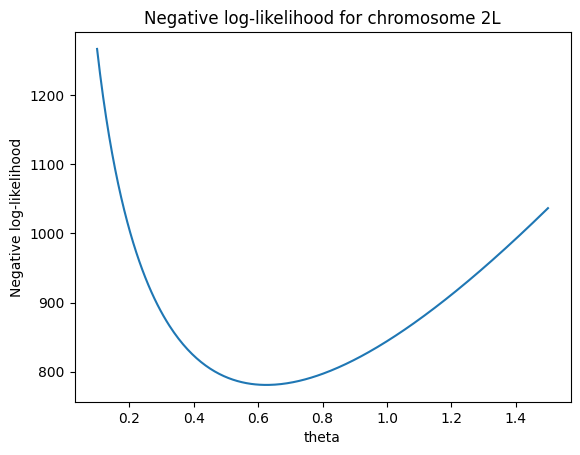

In [8]:
thetas = np.linspace(0.1, 1.5, 300)
nLLs = np.zeros(len(thetas))

for i in range(len(thetas)):

    nLLs[i] = nLL(
        crossover_classes,
        data["2L"],
        thetas[i]
    )

plt.plot(thetas, nLLs)

plt.xlabel("theta")
plt.ylabel("Negative log-likelihood")
plt.title("Negative log-likelihood for chromosome 2L")

plt.show()

In [9]:
best = position_of_min(nLLs)

theta_hat = thetas[best]

print("theta_hat =", theta_hat)

theta_hat = 0.6244147157190635


# Uncertainty of Theta

In [10]:
for chromosome in chromosomes:

    counts = data[chromosome]

    theta = theta_estimate(crossover_classes, counts)
    n = sum(counts)

    se = np.sqrt(theta / n)

    print(chromosome)
    print("theta =", round(theta, 3))
    print("SE =", round(se, 3))

2L
theta = 0.626
SE = 0.028
2R
theta = 0.587
SE = 0.045
3L
theta = 0.71
SE = 0.03
3R
theta = 0.792
SE = 0.032
X
theta = 0.629
SE = 0.029
